In [1]:
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully.")
print("Dataset shape:", X.shape)
print("Features:", iris.feature_names)
print("Classes:", iris.target_names)

Dataset loaded successfully.
Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preprocessing completed successfully.")

Data preprocessing completed successfully.


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.1979 - loss: 1.2030 - val_accuracy: 0.1667 - val_loss: 1.1735
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2292 - loss: 1.1435 - val_accuracy: 0.2083 - val_loss: 1.1282
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3021 - loss: 1.0933 - val_accuracy: 0.4167 - val_loss: 1.0885
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3646 - loss: 1.0502 - val_accuracy: 0.4583 - val_loss: 1.0518
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5417 - loss: 1.0102 - val_accuracy: 0.5000 - val_loss: 1.0159
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6667 - loss: 0.9703 - val_accuracy: 0.5833 - val_loss: 0.9818
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7083 - loss: 0.9310 - val_accuracy: 0.5833 - val_loss: 0.9460
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7396 - loss: 0.8905 - val_accuracy: 0.5833 - 

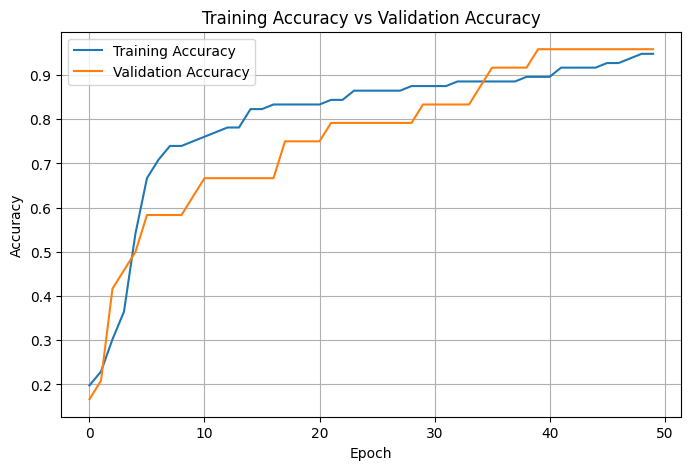

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training Accuracy vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

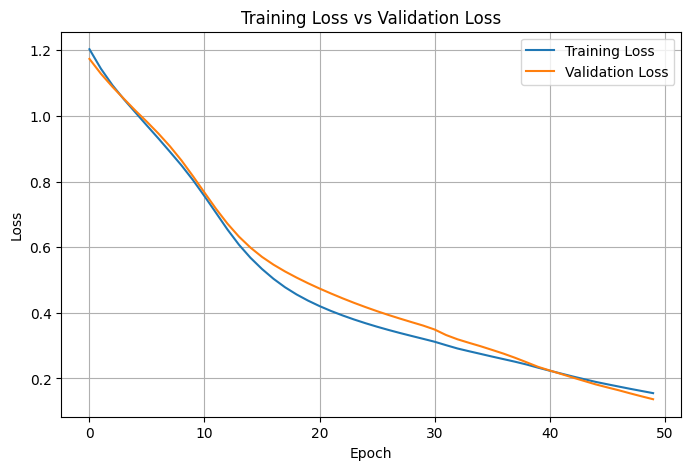

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [10]:
print(
    "Final Training Accuracy:",
    round(history.history["accuracy"][-1] * 100, 2),
    "%"
)

print(
    "Final Validation Accuracy:",
    round(history.history["val_accuracy"][-1] * 100, 2),
    "%"
)

print(
    "Final Training Loss:",
    round(history.history["loss"][-1], 4)
)

print(
    "Final Validation Loss:",
    round(history.history["val_loss"][-1], 4)
)

Final Training Accuracy: 94.79 %
Final Validation Accuracy: 95.83 %
Final Training Loss: 0.1554
Final Validation Loss: 0.1368


##Training and Visualization Analysis
The neural network was trained for 50 epochs using the Iris flower dataset. During the training process, the training accuracy generally increased as the number of epochs increased. This indicates that the neural network gradually learned the relationship between the four input features and the three flower classes. The validation accuracy also improved during training and remained relatively high toward the final epochs.
The training loss and validation loss generally decreased as training progressed. Loss represents the error between the model's predicted classes and the actual classes. Therefore, a reduction in loss shows that the model's predictions became more accurate over time.
From the accuracy and loss graphs, it can be observed that the model improved progressively during training. The training and validation results remained reasonably close to each other. Therefore, there is no strong indication of severe overfitting. Overall, the model successfully learned useful patterns from the Iris dataset and was able to perform well on the validation data.